<a href="https://colab.research.google.com/github/KritiM005/Student_Persona_Clustering/blob/main/Student_Persona_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install umap-learn kmodes -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import KNNImputer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('ai_dependency_career_anxiety_students.csv')
print(df.shape)
df.head()

(15000, 30)


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,resume_confidence_score,interview_anxiety_score,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,Never,1,1,3,2,6,2,11,5,2,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,Rarely,3,7,5,3,8,2,19,4,7,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,Sometimes,4,7,6,3,6,1,15,3,6,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,Frequently,4,4,3,4,7,3,8,5,4,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,Sometimes,4,10,8,5,3,3,5,4,9,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


# EDA

In [49]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (15000, 30)

Dtypes:
 student_id                          object
age                                  int64
gender                              object
degree_type                         object
stream                              object
year_of_study                        int64
college_tier                        object
urban_or_rural                      object
daily_ai_tool_usage_hrs            float64
primary_ai_tools_used               object
uses_ai_for_assignments             object
ai_replaces_own_thinking_score       int64
ai_dependency_score                  int64
placement_anxiety_score              int64
fear_of_job_loss_to_ai               int64
career_clarity_score                 int64
internship_experience                int64
weekly_job_application_count         int64
resume_confidence_score              int64
interview_anxiety_score              int64
daily_study_hours                  float64
self_learning_hours_per_week       float64
skill_development_courses


Missing values:
 primary_ai_tools_used           3215
self_learning_hours_per_week     233
seeks_career_counseling          220
social_media_hrs_per_day         210
sleep_hours                      203
dtype: int64


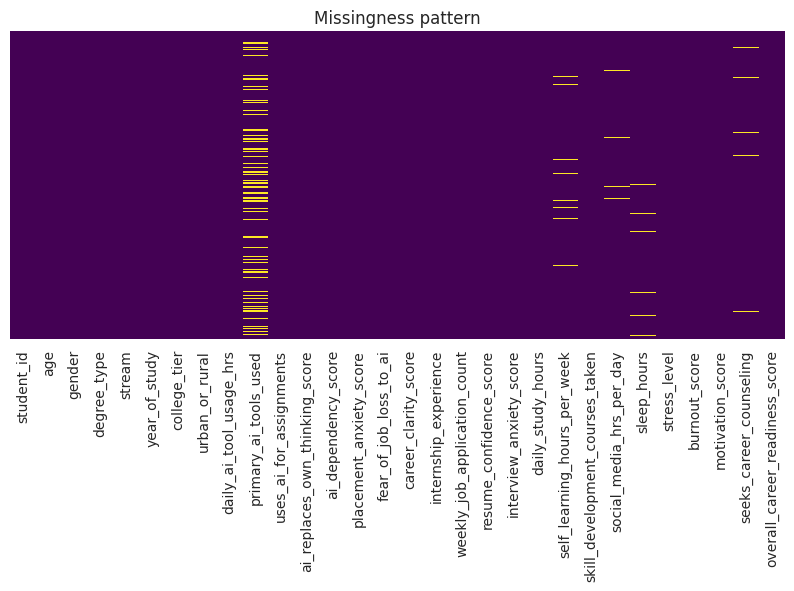

In [50]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("\nMissing values:\n", miss)

plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missingness pattern")
plt.show()

In [51]:
# Confirm primary_ai_tools_used missingness is structural (tied to "Never")
print(df[df['primary_ai_tools_used'].isna()]['uses_ai_for_assignments'].value_counts())

uses_ai_for_assignments
Never    3215
Name: count, dtype: int64


### Numeric column distribution

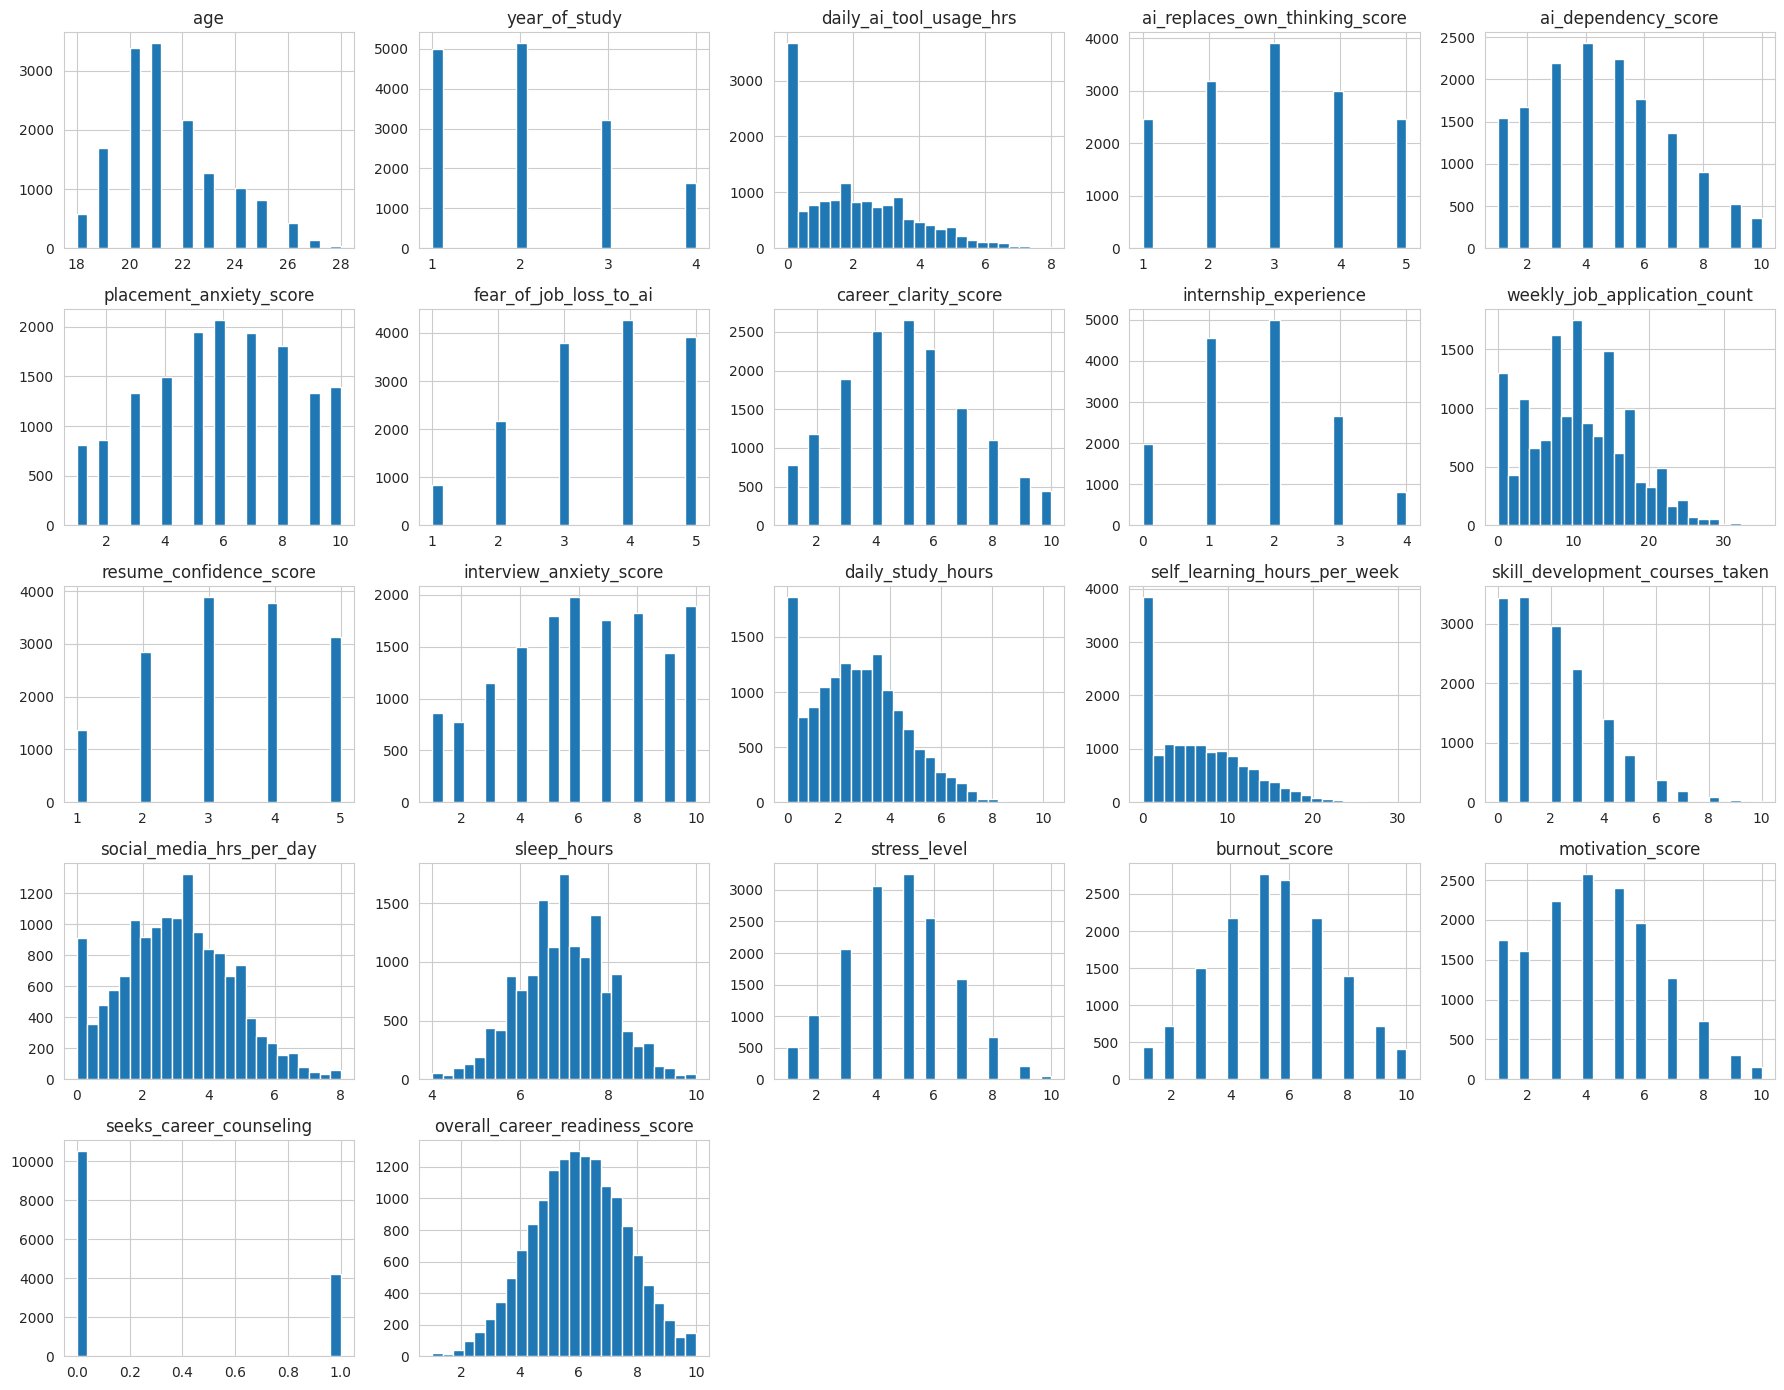

In [52]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].describe().T

df[num_cols].hist(figsize=(18, 14), bins=25)
plt.tight_layout()
plt.show()

### Categorical distributions

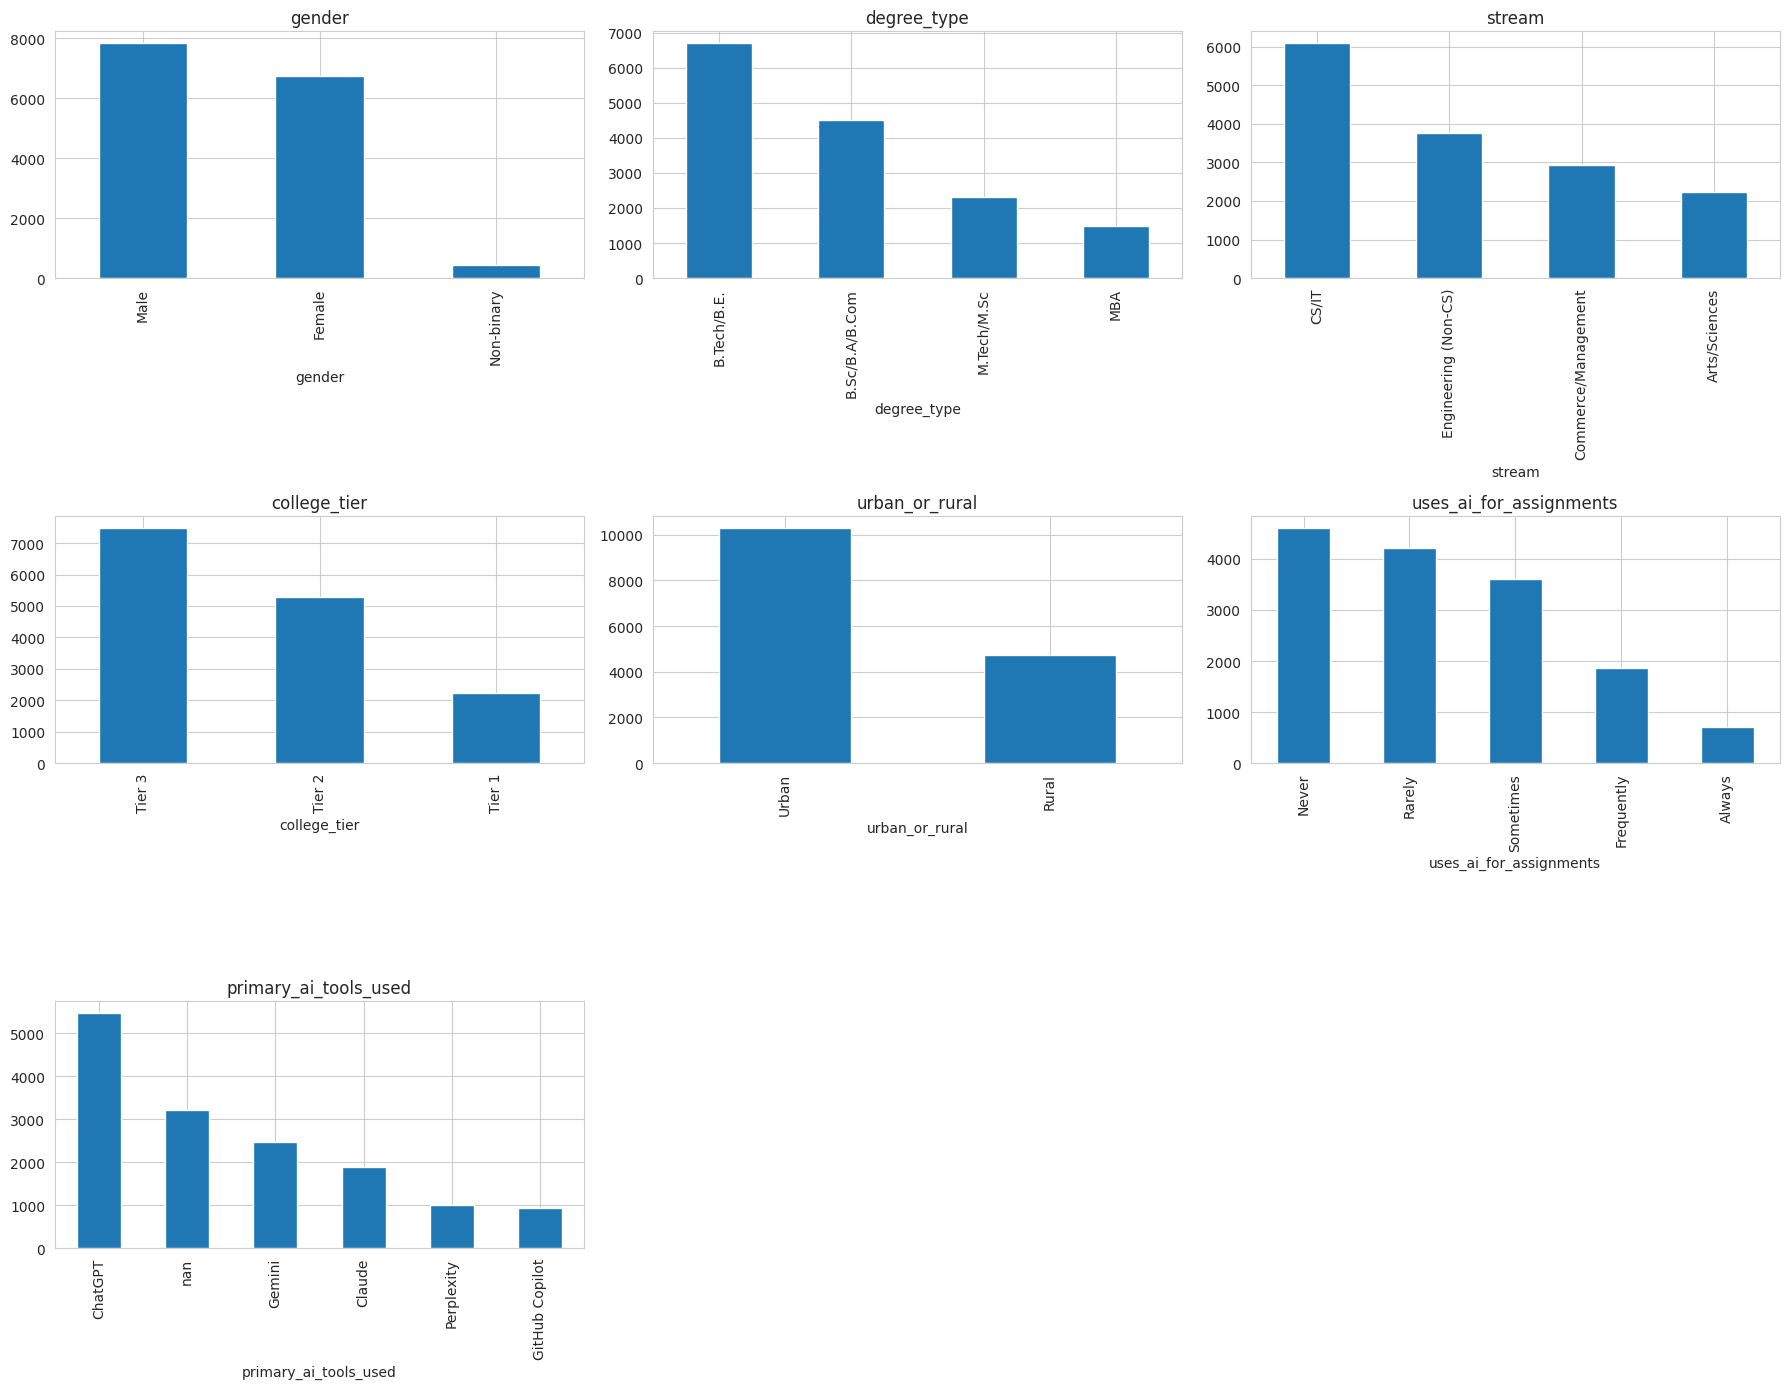

In [53]:
cat_cols = ['gender', 'degree_type', 'stream', 'college_tier', 'urban_or_rural',
            'uses_ai_for_assignments', 'primary_ai_tools_used']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Correlations

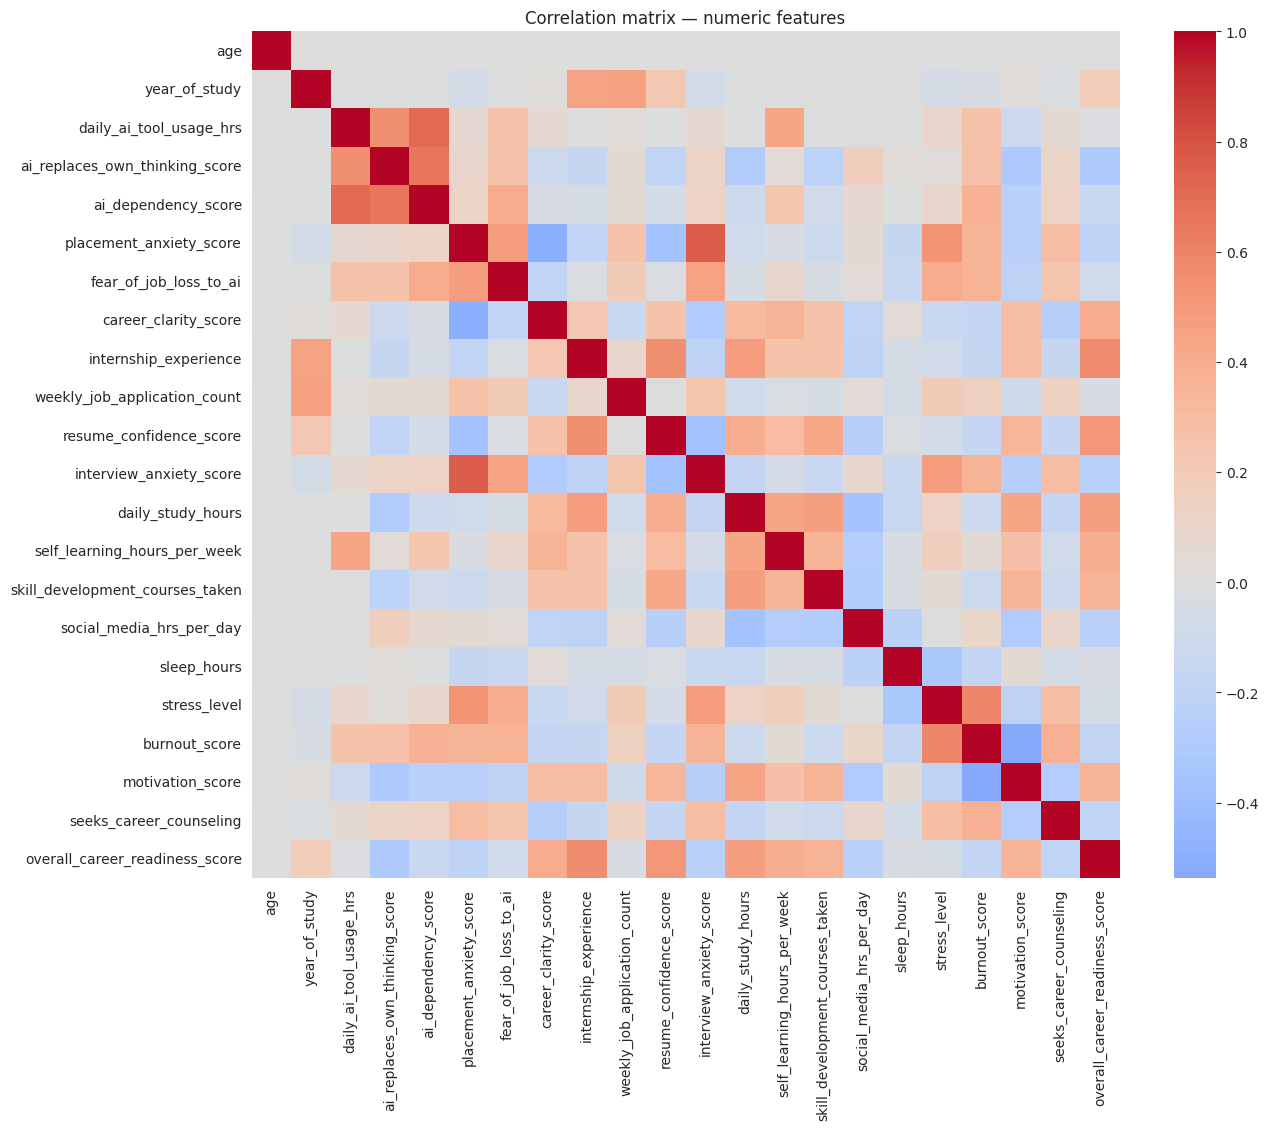

In [54]:
plt.figure(figsize=(14, 11))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation matrix — numeric features")
plt.show()

In [55]:
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("\nPairs with |corr| > 0.6:\n", high_corr[high_corr.abs() > 0.6].sort_values(key=abs, ascending=False))



Pairs with |corr| > 0.6:
 placement_anxiety_score         interview_anxiety_score    0.758246
daily_ai_tool_usage_hrs         ai_dependency_score        0.716250
ai_replaces_own_thinking_score  ai_dependency_score        0.658117
dtype: float64


# Handle Missing Values

In [56]:
df['primary_ai_tools_used'] = df['primary_ai_tools_used'].fillna('None')

# Random-looking missingness -> KNN impute (numeric) using related features
# seeks_career_counseling is binary -> impute with mode after
impute_targets = ['self_learning_hours_per_week', 'social_media_hrs_per_day', 'sleep_hours']

knn_imputer = KNNImputer(n_neighbors=5)
df[impute_targets] = knn_imputer.fit_transform(df[impute_targets])

df['seeks_career_counseling'] = df['seeks_career_counseling'].fillna(
    df['seeks_career_counseling'].mode()[0]
)

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [57]:
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,resume_confidence_score,interview_anxiety_score,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,Never,1,1,3,2,6,2,11,5,2,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,Rarely,3,7,5,3,8,2,19,4,7,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,Sometimes,4,7,6,3,6,1,15,3,6,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,Frequently,4,4,3,4,7,3,8,5,4,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,Sometimes,4,10,8,5,3,3,5,4,9,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


# Preprocessing

In [58]:
# Feature split: clustering features vs profiling-only demographics ---
demographic_cols = ['gender', 'degree_type', 'stream', 'college_tier',
                     'urban_or_rural', 'age', 'year_of_study']  # profiling only, NOT clustered on

id_col = 'student_id'

In [59]:
ordinal_map = [['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always']]
oe = OrdinalEncoder(categories=ordinal_map)
df['uses_ai_for_assignments_enc'] = oe.fit_transform(df[['uses_ai_for_assignments']])

In [60]:
# primary_ai_tools_used is nominal (no order) and about tool choice, not intensity —
# treat as demographic/profiling-only rather than a clustering feature
demographic_cols.append('primary_ai_tools_used')

# Feature Engineering

In [61]:
# Engineered composite indices (helps persona interpretability)
df['ai_reliance_index'] = df[['ai_dependency_score', 'ai_replaces_own_thinking_score',
                                'daily_ai_tool_usage_hrs']].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()), axis=0
).mean(axis=1)

df['wellbeing_index'] = df[['sleep_hours', 'stress_level', 'burnout_score']].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()), axis=0
).assign(stress_level=lambda d: 1 - d['stress_level'],
         burnout_score=lambda d: 1 - d['burnout_score']).mean(axis=1)

In [62]:
# Final clustering feature set ---
clustering_features = [
    'daily_ai_tool_usage_hrs', 'uses_ai_for_assignments_enc',
    'ai_replaces_own_thinking_score', 'ai_dependency_score',
    'placement_anxiety_score', 'fear_of_job_loss_to_ai', 'career_clarity_score',
    'internship_experience', 'weekly_job_application_count',
    'resume_confidence_score', 'interview_anxiety_score',
    'daily_study_hours', 'self_learning_hours_per_week',
    'skill_development_courses_taken', 'social_media_hrs_per_day',
    'sleep_hours', 'stress_level', 'burnout_score', 'motivation_score',
    'seeks_career_counseling', 'overall_career_readiness_score',
    'ai_reliance_index', 'wellbeing_index'
]

# Scaling

In [63]:
X = df[clustering_features].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=df.index)

print("Clustering feature matrix:", X_scaled.shape)
X_scaled.head()

Clustering feature matrix: (15000, 23)


,daily_ai_tool_usage_hrs,uses_ai_for_assignments_enc,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,resume_confidence_score,interview_anxiety_score,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score,ai_reliance_index,wellbeing_index
0,-0.987312,-1.133426,-1.515170,-1.528758,-1.143561,-1.314177,0.442883,0.263351,0.056835,1.366460,-1.557129,0.427182,0.432042,-0.018017,-0.920095,1.506596,-2.120818,-1.195505,0.781085,-0.626085,1.939849,-1.578009,2.074733
1,-0.065610,-0.278698,0.009350,1.062992,-0.358669,-0.466977,1.351671,0.263351,1.306406,0.563447,0.337988,-0.183602,0.341497,0.534641,0.726479,1.306458,-0.433672,-0.228503,-0.613489,-0.626085,0.020064,0.374724,0.781391
2,0.913698,0.576030,0.771611,1.062992,0.033777,-0.466977,0.442883,-0.671624,0.681620,-0.239565,-0.041036,-0.239127,1.826423,-0.570674,-0.432221,0.005564,0.128710,1.705502,-0.613489,1.597228,0.427862,1.035558,-0.914594
3,1.201730,1.430757,0.771611,-0.232883,-1.143561,0.380224,0.897277,1.198327,-0.411754,1.366460,-0.799082,2.759264,1.572899,0.534641,-0.249269,0.205701,0.691093,0.254998,0.781085,-0.626085,1.074064,0.648583,-0.353333
4,0.798486,0.576030,0.771611,2.358867,0.818668,1.227424,-0.920300,1.198327,-0.880344,0.563447,1.096034,-0.183602,-0.944231,-0.018017,-0.676158,1.006252,-0.996054,-0.228503,-0.148631,-0.626085,-0.851995,1.476113,0.915606


In [64]:
# Keep a lookup table for profiling clusters later
profile_df = df[[id_col] + demographic_cols].copy()

# KMeans with Eblow and Silhoette

In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_range = range(2, 11)
inertias = []
sil_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}, "
          f"davies_bouldin={db_scores[-1]:.4f}, calinski_harabasz={ch_scores[-1]:.1f}")


k=2: inertia=287405.9, silhouette=0.1493, davies_bouldin=2.1925, calinski_harabasz=3005.5
k=3: inertia=259902.7, silhouette=0.1239, davies_bouldin=2.1595, calinski_harabasz=2455.2
k=4: inertia=244066.5, silhouette=0.1064, davies_bouldin=2.2439, calinski_harabasz=2067.2
k=5: inertia=231564.0, silhouette=0.1011, davies_bouldin=2.1492, calinski_harabasz=1836.4
k=6: inertia=223307.4, silhouette=0.0913, davies_bouldin=2.1516, calinski_harabasz=1634.2
k=7: inertia=216973.5, silhouette=0.0871, davies_bouldin=2.2172, calinski_harabasz=1474.5
k=8: inertia=211923.7, silhouette=0.0827, davies_bouldin=2.2321, calinski_harabasz=1344.9
k=9: inertia=207986.6, silhouette=0.0766, davies_bouldin=2.3212, calinski_harabasz=1234.4
k=10: inertia=204184.6, silhouette=0.0767, davies_bouldin=2.2906, calinski_harabasz=1148.6


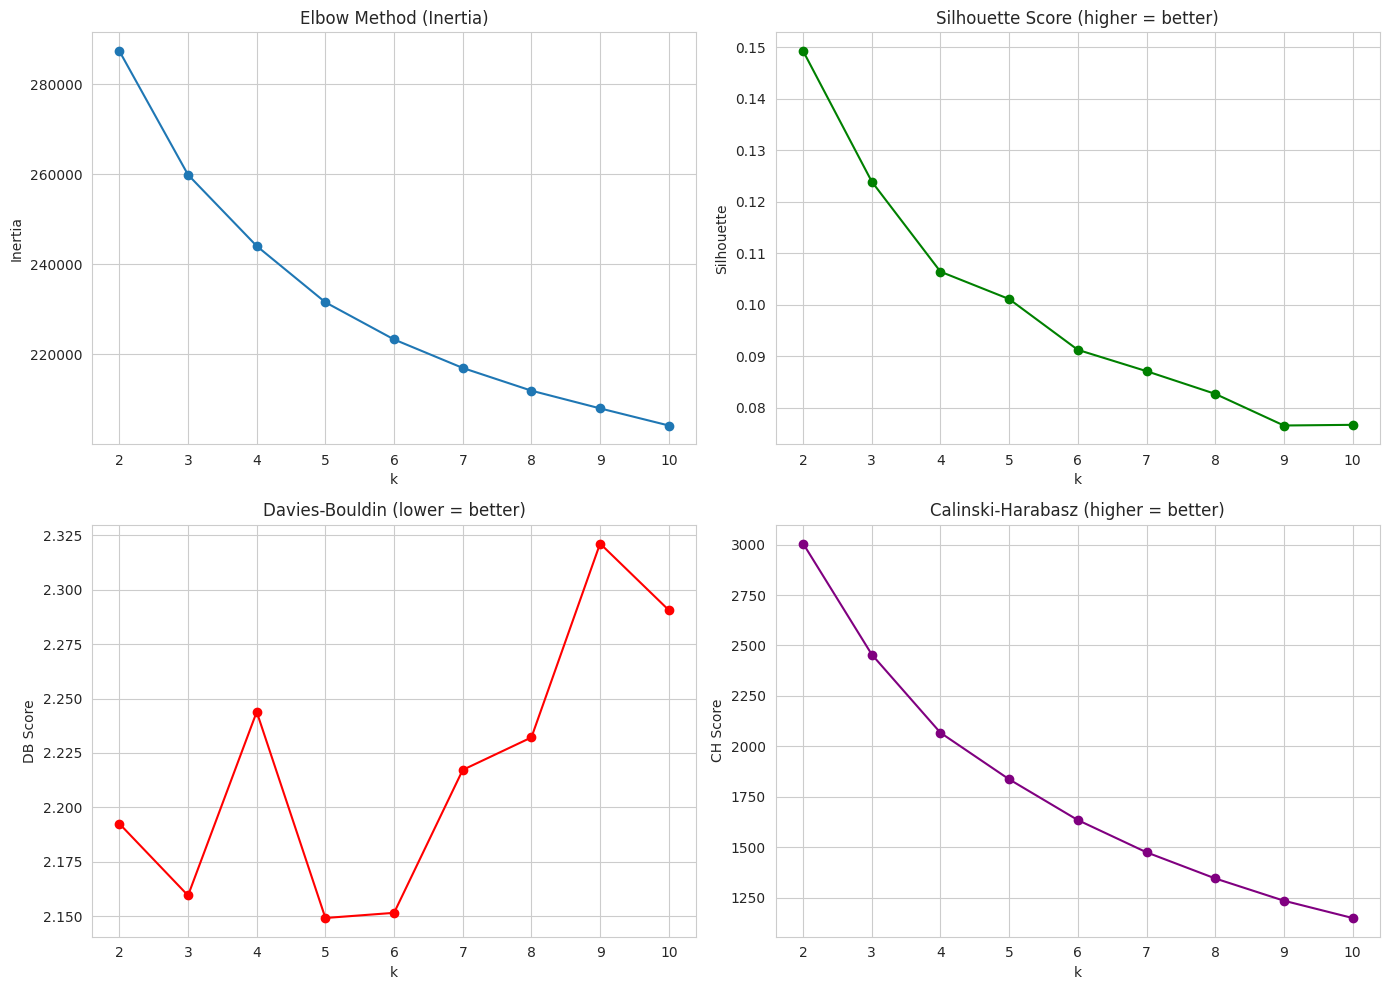

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(k_range, inertias, marker='o')
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')

axes[0,1].plot(k_range, sil_scores, marker='o', color='green')
axes[0,1].set_title('Silhouette Score (higher = better)')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')

axes[1,0].plot(k_range, db_scores, marker='o', color='red')
axes[1,0].set_title('Davies-Bouldin (lower = better)')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('DB Score')

axes[1,1].plot(k_range, ch_scores, marker='o', color='purple')
axes[1,1].set_title('Calinski-Harabasz (higher = better)')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('CH Score')

plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette(X, k):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_sil = silhouette_score(X, labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        cluster_sil_vals = np.sort(sil_vals[labels == i])
        size = cluster_sil_vals.shape[0]
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg_sil, color='red', linestyle='--')
    ax.set_title(f'Silhouette plot — k={k} (avg={avg_sil:.3f})')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster')
    plt.show()
    return labels, avg_sil

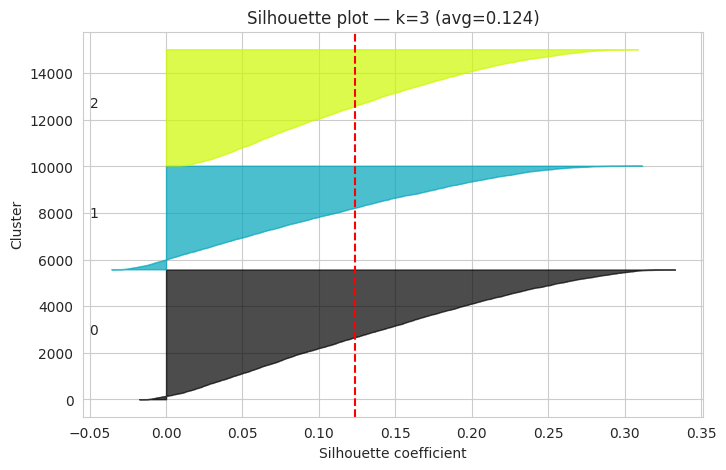

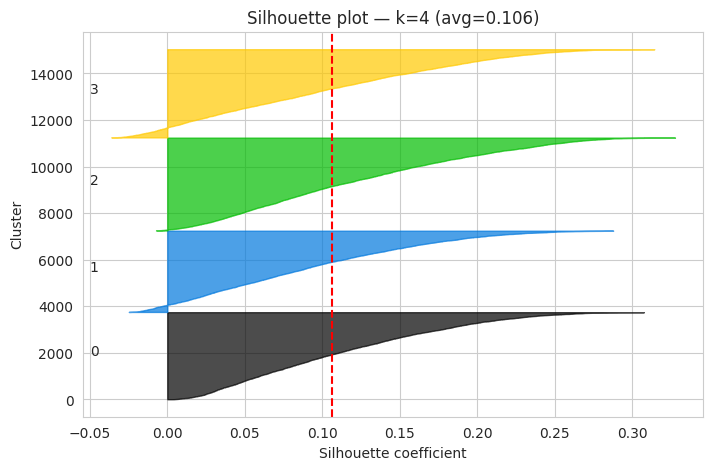

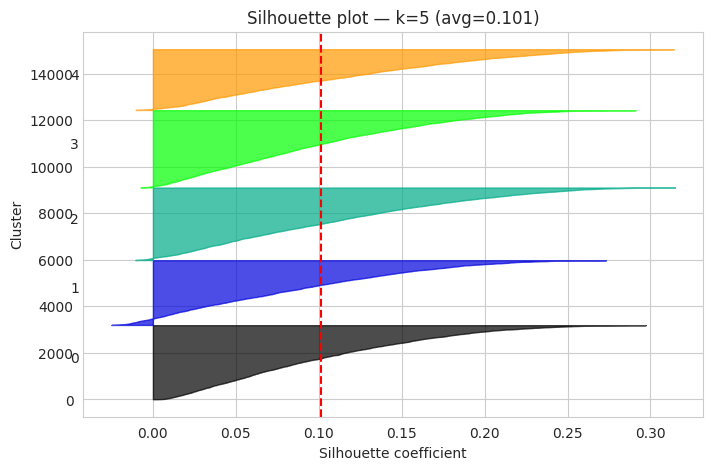

In [68]:
candidate_ks = [3, 4, 5]
for k in candidate_ks:
    plot_silhouette(X_scaled, k)

## Variable Dropping

In [69]:
# Drop the raw features that were folded into composite indices —
# keep either the raw scores OR the index, not both
redundant_raw = ['ai_dependency_score', 'ai_replaces_own_thinking_score', 'daily_ai_tool_usage_hrs',
                  'sleep_hours', 'stress_level', 'burnout_score']

clustering_features_v2 = [c for c in clustering_features if c not in redundant_raw]
X_v2 = df[clustering_features_v2].copy()
X_scaled_v2 = pd.DataFrame(scaler.fit_transform(X_v2), columns=X_v2.columns, index=df.index)
print(X_scaled_v2.shape)

(15000, 17)


## Hopkins Statistics

In [70]:
from sklearn.neighbors import NearestNeighbors
from random import sample

def hopkins_statistic(X, sample_frac=0.1, random_state=42):
    X = np.array(X)
    n = X.shape[0]
    m = int(sample_frac * n)
    rng = np.random.RandomState(random_state)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    idx = rng.choice(n, m, replace=False)
    real_sample = X[idx]
    ud = nbrs.kneighbors(real_sample, n_neighbors=2, return_distance=True)[0][:, 1]

    mins, maxs = X.min(axis=0), X.max(axis=0)
    uniform_sample = rng.uniform(mins, maxs, (m, X.shape[1]))
    wd = nbrs.kneighbors(uniform_sample, n_neighbors=1, return_distance=True)[0][:, 0]

    H = sum(wd) / (sum(ud) + sum(wd))   # <- fixed: wd in numerator
    return H

H = hopkins_statistic(X_scaled_v2)
print(f"Hopkins statistic: {H:.4f}  (near 0.5 = no cluster tendency, near 1 = clusterable)")

Hopkins statistic: 0.6733  (near 0.5 = no cluster tendency, near 1 = clusterable)


## PCA

In [71]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.80, random_state=42)  # keep components explaining 90% variance
X_pca = pca.fit_transform(X_scaled_v2)
print(f"Reduced to {X_pca.shape[1]} components (from {X_scaled_v2.shape[1]})")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")


Reduced to 9 components (from 17)
Explained variance ratio: [0.26810178 0.42489773 0.53286812 0.59883777 0.65410817 0.70254314
 0.7485131  0.79011062 0.82912875]


# Revised KMeans Clustering

In [72]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    print(f"k={k}: silhouette={silhouette_score(X_pca, labels):.4f}, "
          f"davies_bouldin={davies_bouldin_score(X_pca, labels):.4f}")

k=2: silhouette=0.1883, davies_bouldin=1.8593
k=3: silhouette=0.1437, davies_bouldin=1.9269
k=4: silhouette=0.1335, davies_bouldin=1.8560
k=5: silhouette=0.1328, davies_bouldin=1.8506
k=6: silhouette=0.1189, davies_bouldin=1.8829
k=7: silhouette=0.1122, davies_bouldin=1.9133
k=8: silhouette=0.1083, davies_bouldin=1.9571
k=9: silhouette=0.1061, davies_bouldin=1.9750
k=10: silhouette=0.1058, davies_bouldin=1.9571


In [73]:
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, init='k-means++', n_init=10, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_pca)

print(df['cluster'].value_counts().sort_index())
print(f"\nFinal silhouette: {silhouette_score(X_pca, df['cluster']):.4f}")
print(f"Final Davies-Bouldin: {davies_bouldin_score(X_pca, df['cluster']):.4f}")

cluster
0    3403
1    3896
2    3496
3    4205
Name: count, dtype: int64

Final silhouette: 0.1335
Final Davies-Bouldin: 1.8560


## tsne

In [74]:
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

## UMAP

In [75]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_pca)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


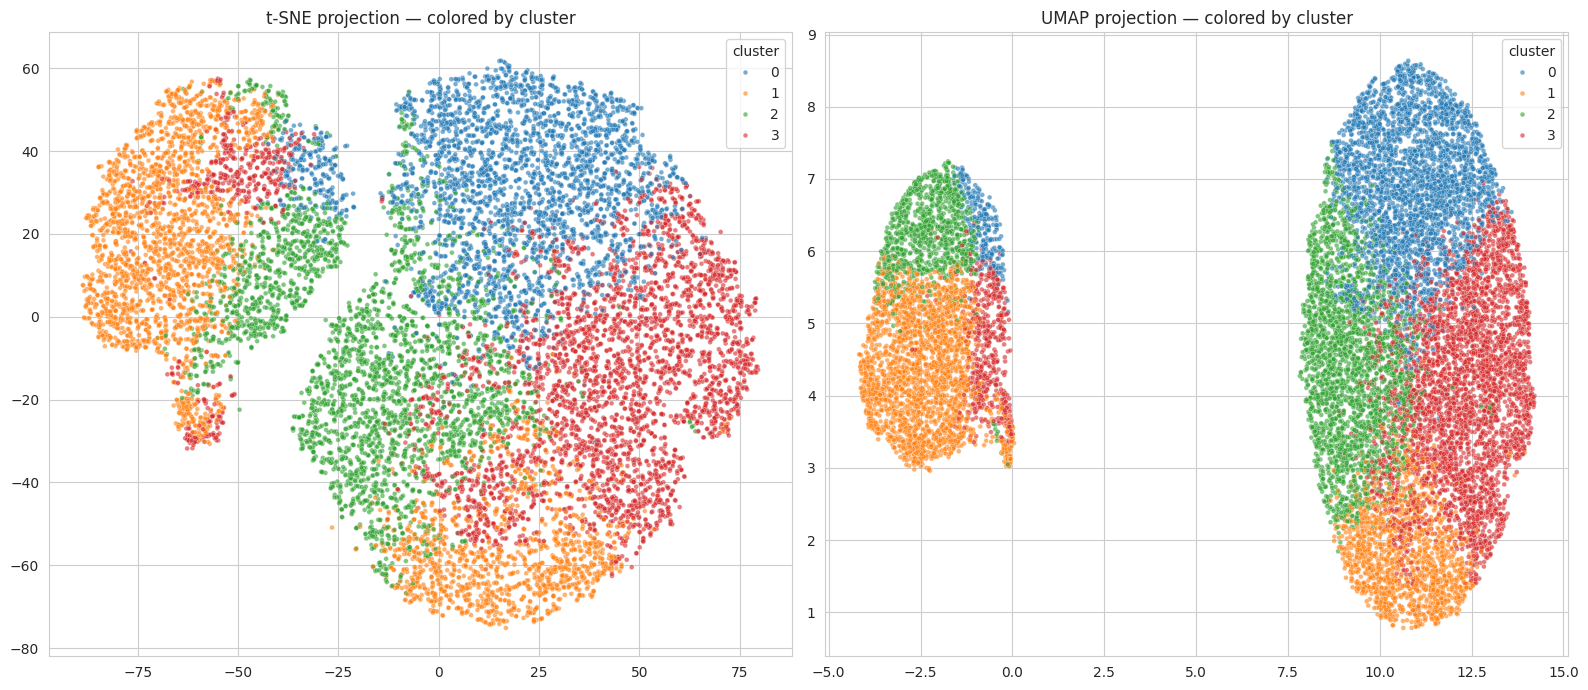

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['cluster'], palette='tab10',
                 s=12, alpha=0.6, ax=axes[0], legend='full')
axes[0].set_title('t-SNE projection — colored by cluster')

sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=df['cluster'], palette='tab10',
                 s=12, alpha=0.6, ax=axes[1], legend='full')
axes[1].set_title('UMAP projection — colored by cluster')

plt.tight_layout()
plt.show()

# Nested KMeans

In [77]:
kmeans_l1 = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
df['cluster_l1'] = kmeans_l1.fit_predict(X_pca)

print("Top-level split sizes:")
print(df['cluster_l1'].value_counts().sort_index())
print(f"Top-level silhouette: {silhouette_score(X_pca, df['cluster_l1']):.4f}")

Top-level split sizes:
cluster_l1
0    7426
1    7574
Name: count, dtype: int64
Top-level silhouette: 0.1883


In [78]:
sub_k_results = {}

for l1_val in sorted(df['cluster_l1'].unique()):
    mask = df['cluster_l1'] == l1_val
    X_sub = X_pca[mask.values]

    print(f"\n--- Sub-clustering within cluster_l1={l1_val} (n={mask.sum()}) ---")
    sub_sil = []
    for k in range(2, 6):  # keep sub-k range modest — you're already splitting a subset
        km_sub = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels_sub = km_sub.fit_predict(X_sub)
        sil = silhouette_score(X_sub, labels_sub)
        sub_sil.append(sil)
        print(f"  sub-k={k}: silhouette={sil:.4f}, davies_bouldin={davies_bouldin_score(X_sub, labels_sub):.4f}")

    sub_k_results[l1_val] = sub_sil


--- Sub-clustering within cluster_l1=0 (n=7426) ---
  sub-k=2: silhouette=0.1573, davies_bouldin=2.1498
  sub-k=3: silhouette=0.1341, davies_bouldin=2.1433
  sub-k=4: silhouette=0.1323, davies_bouldin=1.9299
  sub-k=5: silhouette=0.1222, davies_bouldin=1.9169

--- Sub-clustering within cluster_l1=1 (n=7574) ---
  sub-k=2: silhouette=0.1397, davies_bouldin=2.3286
  sub-k=3: silhouette=0.1218, davies_bouldin=2.1817
  sub-k=4: silhouette=0.1237, davies_bouldin=1.9656
  sub-k=5: silhouette=0.1177, davies_bouldin=2.0096


In [79]:
SUB_K = {0: 2, 1: 2}   # <-- EDIT after seeing 6.2 output — pick each branch's silhouette peak

df['cluster_l2'] = -1  # sub-cluster id within its branch
for l1_val, k in SUB_K.items():
    mask = df['cluster_l1'] == l1_val
    X_sub = X_pca[mask.values]
    km_sub = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    df.loc[mask, 'cluster_l2'] = km_sub.fit_predict(X_sub)

In [80]:
df['persona'] = df['cluster_l1'].astype(str) + '_' + df['cluster_l2'].astype(str)

print("\nFinal nested persona sizes:")
print(df['persona'].value_counts().sort_index())


Final nested persona sizes:
persona
0_0    3388
0_1    4038
1_0    3491
1_1    4083
Name: count, dtype: int64


In [81]:
from sklearn.preprocessing import LabelEncoder
persona_encoded = LabelEncoder().fit_transform(df['persona'])
print(f"\nFlattened nested-clustering silhouette: {silhouette_score(X_pca, persona_encoded):.4f}")
print(f"Flattened nested-clustering Davies-Bouldin: {davies_bouldin_score(X_pca, persona_encoded):.4f}")


Flattened nested-clustering silhouette: 0.1146
Flattened nested-clustering Davies-Bouldin: 2.2392


## tsne

In [82]:
from sklearn.manifold import TSNE
import umap

tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

df['tsne_x'] = X_tsne[:, 0]
df['tsne_y'] = X_tsne[:, 1]

## UMAP

In [83]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_pca)

df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


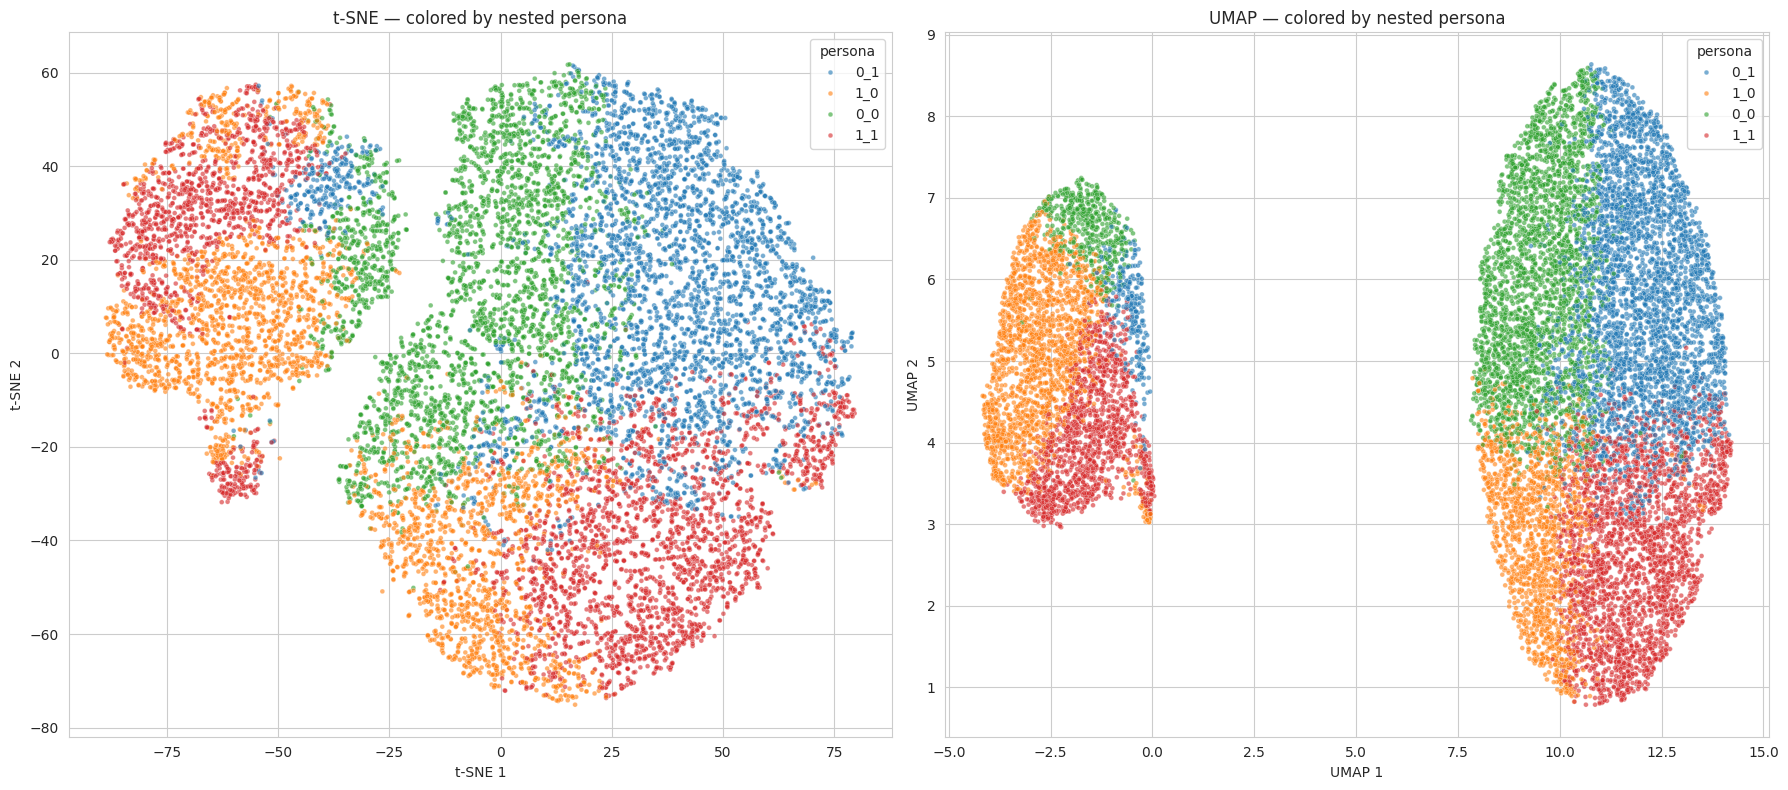

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.scatterplot(x='tsne_x', y='tsne_y', hue='persona', data=df, palette='tab10',
                 s=12, alpha=0.6, ax=axes[0], legend='full')
axes[0].set_title('t-SNE — colored by nested persona')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

sns.scatterplot(x='umap_x', y='umap_y', hue='persona', data=df, palette='tab10',
                 s=12, alpha=0.6, ax=axes[1], legend='full')
axes[1].set_title('UMAP — colored by nested persona')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# Comparison

In [85]:
# Flattened nested solution (already computed)
print(f"Nested (flattened) silhouette: {silhouette_score(X_pca, persona_encoded):.4f}")

# Flat k=4, for direct comparison
kmeans_4 = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
flat4_labels = kmeans_4.fit_predict(X_pca)
print(f"Flat k=4 silhouette: {silhouette_score(X_pca, flat4_labels):.4f}")
print(f"Flat k=4 Davies-Bouldin: {davies_bouldin_score(X_pca, flat4_labels):.4f}")

Nested (flattened) silhouette: 0.1146
Flat k=4 silhouette: 0.1335
Flat k=4 Davies-Bouldin: 1.8560


In [86]:
df['cluster'] = flat4_labels
print(df['cluster'].value_counts().sort_index())

cluster
0    3403
1    3896
2    3496
3    4205
Name: count, dtype: int64


# Cluster Profiling

In [87]:
# --- Mean feature values per cluster (original scale) ---
persona_profile = df.groupby('cluster')[clustering_features_v2].mean().round(2)
persona_profile['n_students'] = df['cluster'].value_counts().sort_index()
persona_profile['pct'] = (persona_profile['n_students'] / len(df) * 100).round(1)
print(persona_profile.T)


cluster                                0        1        2        3
uses_ai_for_assignments_enc         0.97     1.38     2.28     0.77
placement_anxiety_score             4.00     8.05     6.78     4.77
fear_of_job_loss_to_ai              2.90     4.21     4.28     2.86
career_clarity_score                6.56     3.29     5.47     5.02
internship_experience               2.54     1.00     2.12     1.38
weekly_job_application_count        8.86    12.43    12.10     9.20
resume_confidence_score             4.39     2.34     3.71     2.96
interview_anxiety_score             4.02     8.23     6.92     5.16
daily_study_hours                   4.30     1.57     3.45     1.94
self_learning_hours_per_week        8.86     3.64    10.70     3.08
skill_development_courses_taken     3.42     1.03     2.62     1.35
social_media_hrs_per_day            2.14     3.70     2.60     3.41
motivation_score                    6.23     2.74     4.34     4.22
seeks_career_counseling             0.08     0.6

## Heatmap

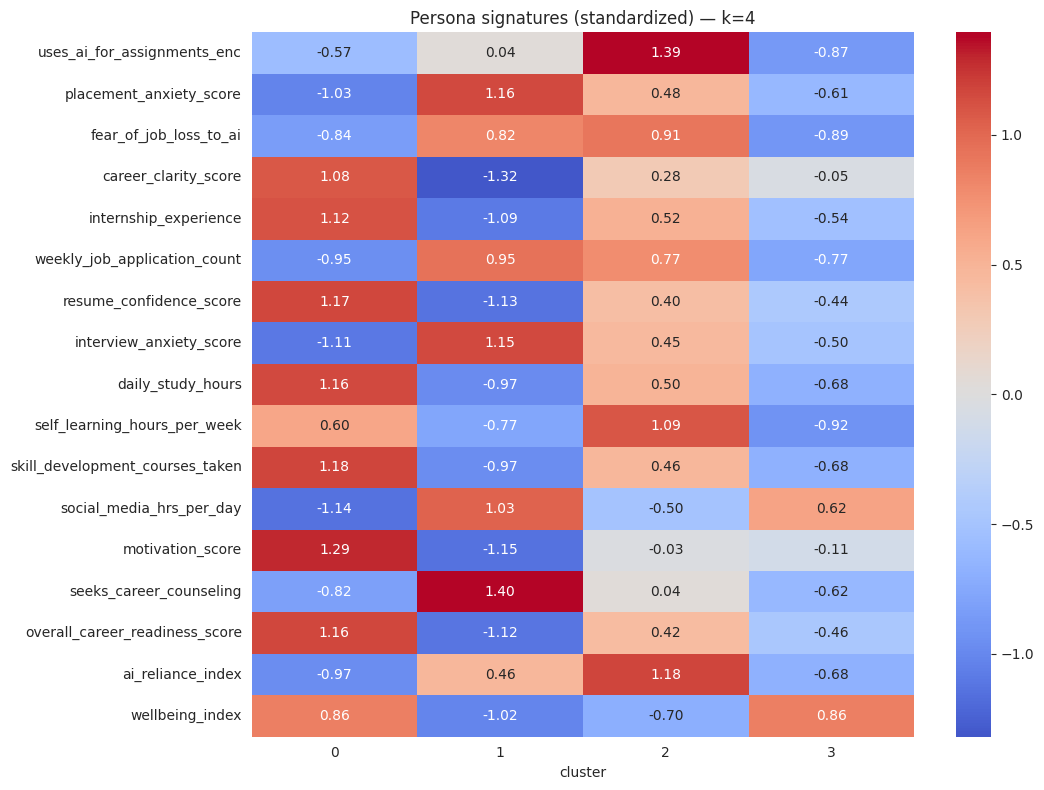

In [88]:
z = (persona_profile[clustering_features_v2] - persona_profile[clustering_features_v2].mean()) / persona_profile[clustering_features_v2].std()
plt.figure(figsize=(11, 8))
sns.heatmap(z.T, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Persona signatures (standardized) — k=4')
plt.tight_layout()
plt.show()